## Imports

In [24]:
from bs4 import BeautifulSoup
import networkx as nx
import matplotlib.pyplot as plt

import numpy as np

## Parse all Bobu transactions

In [6]:
all_transactions = []


cnt = 1
date_ = "april_18"
asset_type = "bobu"

fn = "../../data/{}_{}_{}.html".format(asset_type, date_, cnt)

while True:
    try:
        with open(fn, "r") as fp:
            print("Parsing {} ...".format(fn))
            html = fp.read()
            soup = BeautifulSoup(html)
            lisitem_divs = soup.findAll('div', {'role': 'listitem'})
            for item in lisitem_divs:
                divs = item.findAll('div', {'display': 'flex'})
                data = {}
                data["{}_id".format(asset_type)] = divs[1].text
                prices = divs[2].text.split(" ")
                try:
                    data["eth"] = prices[0]
                except IndexError:
                    data["eth"] = -1
                try:
                    data["usd"] = prices[1]
                except IndexError:
                    data["usd"] = -1
                data["cnt"] = divs[3].text
                data["sender"] = divs[4].text
                data["receiver"] = divs[5].text
                data["date"] = divs[6].text
                all_transactions.append(data)
        cnt += 1
        # proceed to next file
        fn = "../../data/{}_{}_{}.html".format(asset_type, date_, cnt)
    except FileNotFoundError:
        break

Parsing ../../data/bobu_april_18_1.html ...
Parsing ../../data/bobu_april_18_2.html ...
Parsing ../../data/bobu_april_18_3.html ...
Parsing ../../data/bobu_april_18_4.html ...
Parsing ../../data/bobu_april_18_5.html ...
Parsing ../../data/bobu_april_18_6.html ...
Parsing ../../data/bobu_april_18_7.html ...


In [7]:
all_transactions

[{'bobu_id': 'Bobu Token (Azuki #40) ',
  'eth': '0.183',
  'usd': '$557.39',
  'cnt': '1',
  'sender': 'HalloweenMonstaTruck',
  'receiver': 'ThrashToGold',
  'date': '2 hours ago open_in_new'},
 {'bobu_id': 'Bobu Token (Azuki #40) ',
  'eth': '0.198',
  'usd': '$603.08',
  'cnt': '1',
  'sender': 'xiaolou888.eth',
  'receiver': 'HandsOffMyFathersBead...',
  'date': '2 hours ago open_in_new'},
 {'bobu_id': 'Bobu Token (Azuki #40) ',
  'eth': '0.2',
  'usd': '$609.17',
  'cnt': '1',
  'sender': 'jep987',
  'receiver': 'NFTxFamily',
  'date': '3 hours ago open_in_new'},
 {'bobu_id': 'Bobu Token (Azuki #40) ',
  'eth': '0.205',
  'usd': '$624.40',
  'cnt': '1',
  'sender': 'yyyyz',
  'receiver': 'Nuggernaut',
  'date': '3 hours ago open_in_new'},
 {'bobu_id': 'Bobu Token (Azuki #40) ',
  'eth': '0.199',
  'usd': '$606.12',
  'cnt': '1',
  'sender': 'F7F664',
  'receiver': 'B15438',
  'date': '3 hours ago open_in_new'},
 {'bobu_id': 'Bobu Token (Azuki #40) ',
  'eth': '0.183',
  'usd': '$

## Review data

In [8]:
print("No of transactions: {}".format(len(all_transactions)))

No of transactions: 140


## Find Top k Most expensive transactions

In [40]:
bobu_prices = {}


for trans in all_transactions:
    try:
        sender = trans["sender"]
        rcvr = trans["receiver"]
        price = trans["eth"]
        key = sender + ";@;" + rcvr
        bobu_prices[key] = float(price)
    except KeyError:
        continue

In [41]:
len(bobu_prices)

119

## Sort dict by value

In [42]:
dict(sorted(bobu_prices.items(), key=lambda item: item[1], reverse=True))

{'AllThatGlittersIsNotG...;@;rubbtoshi': 1.145,
 'bobagum;@;Wizofecom': 0.6,
 'BB9DB6;@;hujun': 0.6,
 'vladen;@;Wizofecom': 0.57,
 'Chuckle-Toots;@;hyperion.eth': 0.418,
 '352988;@;Com': 0.416,
 'fourtw0four424;@;84761F': 0.38,
 'O_J_A;@;rubbtoshi': 0.23,
 'Robot5555;@;Rxas': 0.225,
 'SSS24;@;rubbtoshi': 0.225,
 'UniqDigitalArtCollect...;@;rubbtoshi': 0.225,
 'gimmemymillivanilli;@;rubbtoshi': 0.225,
 'Pug-King;@;rubbtoshi': 0.223,
 'CuneytKarpat;@;rubbtoshi': 0.222,
 'Bearly_V2;@;soygirl': 0.22,
 '3JOH22A;@;rubbtoshi': 0.22,
 'KDotsLeftStrokeHW;@;rubbtoshi': 0.22,
 '_NFtnERD;@;seanhales': 0.219,
 'FEFE31;@;GOLDFACE': 0.219,
 'akadongdong;@;MetaMax211': 0.218,
 'MarionesNFT;@;BaibaiYee': 0.216,
 'biglee103;@;dreamer202': 0.215,
 'rudekoji;@;SAN10': 0.214,
 '225D8A;@;6352': 0.212,
 'carlisle;@;jamessorensen.eth': 0.21,
 'tatertotss;@;hammadbarak': 0.21,
 'Nicofcz;@;3469E9': 0.21,
 '1pal;@;Braiker': 0.21,
 'SalsFortune;@;5A5572': 0.21,
 'Trimaan;@;LinGuni': 0.21,
 '932B20;@;Jtriple': 0.2

## Plot Bobu distribution

In [43]:
bobu_price_vals = np.array(list(bobu_prices.values()))

In [44]:
bobu_price_vals

array([0.183, 0.198, 0.2  , 0.205, 0.199, 0.183, 0.199, 0.2  , 0.2  ,
       0.19 , 0.194, 0.199, 0.19 , 0.2  , 0.215, 0.21 , 0.2  , 0.197,
       0.19 , 0.208, 0.208, 0.205, 0.2  , 0.209, 0.19 , 0.21 , 0.216,
       0.21 , 0.214, 0.209, 0.2  , 0.19 , 0.185, 0.192, 0.17 , 0.57 ,
       0.2  , 0.194, 0.185, 0.195, 0.199, 0.2  , 0.194, 0.19 , 0.194,
       0.193, 0.183, 0.19 , 0.2  , 0.6  , 0.38 , 0.195, 0.192, 0.189,
       0.197, 0.19 , 0.2  , 0.182, 0.19 , 0.198, 0.192, 0.181, 0.2  ,
       0.199, 0.2  , 0.198, 0.14 , 0.204, 0.204, 0.205, 0.19 , 0.21 ,
       0.206, 0.202, 0.206, 0.416, 0.218, 0.212, 0.195, 0.2  , 0.2  ,
       0.21 , 0.22 , 0.219, 0.225, 0.2  , 0.219, 0.418, 0.2  , 0.195,
       0.6  , 0.194, 0.2  , 0.191, 0.2  , 0.204, 0.205, 0.205, 0.201,
       0.208, 0.225, 0.225, 0.222, 0.22 , 0.22 , 0.223, 0.225, 0.23 ,
       1.145, 0.209, 0.21 , 0.2  , 0.21 , 0.202, 0.208, 0.201, 0.2  ,
       0.21 , 0.208])

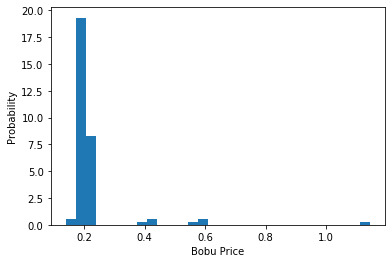

In [47]:
%matplotlib inline

plt.hist(bobu_price_vals, density=True, bins=30)  # density=False would make counts
plt.ylabel('Probability')
plt.xlabel('Bobu Price');

In [49]:
mean_ = round(np.mean(bobu_price_vals), 4)
std_ = round(np.std(bobu_price_vals), 4)

print("Mean of Bobu price: {}".format(mean_))
print("Std of Bobu price: {}".format(std_))

Mean of Bobu price: 0.224
Std of Bobu price: 0.1094


## Generate Graph

In [27]:
g = nx.Graph()

for trans in all_transactions:
    try:
        items = trans["bobu_id"].split(" #")
        azuki_id = items[1].strip()
    except IndexError:
        continue

    #if azuki_id in set(hub_azukis):
    #if azuki_id in set(interesting_azukis):
        #print(azuki_id)
    sendr, rcvr = trans["sender"], trans["receiver"]
    g.add_edge(sendr, rcvr)

## Draw graph

//anaconda/envs/uatu/lib/python3.7/site-packages/networkx/drawing/nx_pylab.py:579: MatplotlibDeprecationWarning: 
The iterable function was deprecated in Matplotlib 3.1 and will be removed in 3.3. Use np.iterable instead.
  if not cb.iterable(width):


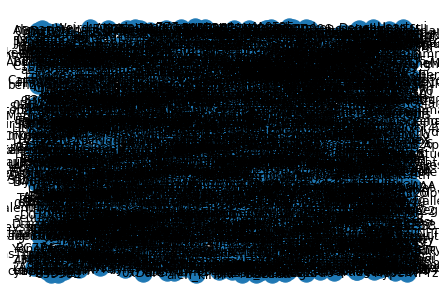

In [28]:
# clearing the current plot
plt.clf()
 
# drawing in random layout
nx.draw_random(g, with_labels = True)

# # drawing in circular layout
# nx.draw_circular(g, with_labels = True)

plt.savefig("bobu_1.png")

In [29]:
g.degree

DegreeView({'TheCodeater': 1, '4DDF67': 4, 'louishuyi': 1, '44A050': 1, 'Marcus95': 1, 'Elsasisalin': 2, 'sngls.eth': 1, '998Iok': 1, '4714A7': 1, 'Luckyyy': 2, 'FC9B16': 1, 'gabadook': 2, 'Elan3': 1, 'BE387B': 1, '84D20B': 2, 'RangerCov175': 1, 'orreo112': 2, 'Milderketchup': 1, 'samurairai': 1, 'Hunger_Brainz': 1, 'babybearrrr': 1, 'Aviann': 1, 'consnovvvv': 1, 'bigoncrypto': 1, 'B88F5A': 2, 'sexboy11223': 1, 'SirSunshines': 1, 'Startfrom0': 1, 'B27DA1': 3, 'choppalit': 1, 'D00100': 1, 'alwinn': 1, 'szww': 1, 'NikitosETH': 1, 'unnamedbot': 1, 'UNIVAC2NFT': 1, 'BopBop': 1, 'C2AC96': 1, 'ToiletSeatInvestor': 1, 'B2FED4': 1, 'CG12031': 1, 'dimitarnikolov': 1, '2Q2POOT': 1, '000069eth': 1, 'Kimchie': 1, 'ilovedreamland': 1, 'Charles001': 1, 'LevoPhobia': 1, '4E71E2': 1, 'LLAMADAGOAT': 1, 'MollyGor': 1, '009F40': 1, 'acelovesnft': 1, 'AmanditaHot': 1, 'Papasmurftm': 1, '7AEDE9': 1, '3DB10D': 1, 'CMPN': 1, 'L0B0S0LITARI0': 1, 'F32DF0': 1, '4ACF83': 1, '39684B': 1, 'gsumagang': 1, 'jeron1mo

In [32]:
sorted(g.degree, key=lambda x: x[1], reverse=True)[:20]

[('getmeoutofthisproject', 54),
 ('35FA01', 20),
 ('AaaaaaaaNFT', 18),
 ('sneakyninjapants', 14),
 ('lovedraco', 9),
 ('D39805', 8),
 ('TraderJ', 7),
 ('LiveFreeOrDie', 6),
 ('HomeLowes', 6),
 ('SatoshisMom', 6),
 ('905679', 5),
 ('nonnonnonnon', 5),
 ('itsMoon64', 5),
 ('4DDF67', 4),
 ('F83475', 4),
 ('smangtrain66', 4),
 ('CryptoEveryday', 4),
 ('EmergenSea', 4),
 ('4A9A0F', 4),
 ('DA3DED', 4)]